# Rebuttal: Neural Networks Can Easily Learn the Game of Life

This notebook serves as a rebuttal to the paper "It's Hard for Neural Networks To Learn the Game of Life" (arXiv:2009.01398). We tried to demonstrate that with a standard Convolutional Neural Network (CNN) architecture and proper training data generation, a neural network can learn the rules of Conway's Game of Life (GoL) to near-perfect accuracy.

## Setup and Imports

In [7]:
import sys
import subprocess

# Auto-install dependencies if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab. Installing dependencies...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow", "numpy", "matplotlib", "scipy"])
except ImportError:
    IN_COLAB = False
    print("Running locally.")

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from scipy.signal import convolve2d
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

Running locally.
TensorFlow Version: 2.20.0
GPU Available: False


## 1. Data Generation

We generate a dataset of Game of Life grids. Crucially, we vary the initial density of live cells to ensure the model sees a diverse range of patterns, preventing it from overfitting to specific densities.

In [8]:
def game_of_life_step(grid):
    """
    Performs one step of Conway's Game of Life using convolution.
    """
    kernel = np.array([[1, 1, 1],
                       [1, 0, 1],
                       [1, 1, 1]])
    neighbors = convolve2d(grid, kernel, mode='same', boundary='fill', fillvalue=0)
    survives = (grid == 1) & ((neighbors == 2) | (neighbors == 3))
    births = (grid == 0) & (neighbors == 3)
    return (survives | births).astype(np.float32)

def generate_data(num_samples, grid_size):
    """
    Generates (input, target) pairs.
    Input: Random grid
    Target: Grid after 1 step of GoL
    """
    X = np.zeros((num_samples, grid_size, grid_size, 1), dtype=np.float32)
    y = np.zeros((num_samples, grid_size, grid_size, 1), dtype=np.float32)

    for i in range(num_samples):
        # Random density between 0.1 and 0.9 to ensure diversity
        density = np.random.uniform(0.1, 0.9)
        state = np.random.choice([0, 1], size=(grid_size, grid_size), p=[1-density, density])
        next_state = game_of_life_step(state)
        
        X[i, :, :, 0] = state
        y[i, :, :, 0] = next_state
        
    return X, y

# Configuration
GRID_SIZE = 20
NUM_TRAIN = 10000
NUM_VAL = 2000

print("Generating Data...")
X_train, y_train = generate_data(NUM_TRAIN, GRID_SIZE)
X_val, y_val = generate_data(NUM_VAL, GRID_SIZE)
print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}")

Generating Data...
Train shape: (10000, 20, 20, 1), Val shape: (2000, 20, 20, 1)


## 2. Model Architecture

We use a simple CNN. The Game of Life rules are local (3x3 neighborhood), so a CNN is naturally suited for this. 

We use two convolutional layers:
1. **Layer 1**: 3x3 filters to capture the neighborhood state.
2. **Layer 2**: 1x1 filters (or another 3x3) to map the features to the next state (dead or alive).

This architecture is sufficient to represent the rules perfectly.

In [9]:
def build_model(grid_size):
    model = models.Sequential([
        layers.Input(shape=(grid_size, grid_size, 1)),
        
        # First layer: Capture local 3x3 patterns
        # We use enough filters to represent various neighborhood counts
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        
        # Second layer: More processing, can be 1x1 or 3x3
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        
        # Output layer: 1x1 convolution to produce probability map
        layers.Conv2D(1, (1, 1), padding='same', activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_model(GRID_SIZE)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 20, 20, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 20, 20, 1)      │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,633 (147.00 KB)

 Trainable params: 37,633 (147.00 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Training

We train the model for a few epochs. Given the simplicity of the task for a CNN, it should converge very quickly.

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.7945 - loss: 0.4693 - val_accuracy: 0.9287 - val_loss: 0.2193
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9626 - loss: 0.1458 - val_accuracy: 0.9989 - val_loss: 0.0217
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9994 - loss: 0.0150 - val_accuracy: 1.0000 - val_loss: 0.0051
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 7.7524e-04
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 1.0000 - loss: 7.0678e-04 - val_accuracy: 1.0000 - val_loss: 5.3038e-04
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 1.0000 - los

## 4. Evaluation

We evaluate the model not just on pixel accuracy, but on **exact match accuracy** (percentage of grids where EVERY cell is predicted correctly).

In [11]:
def evaluate_exact_match(model, X, y):
    preds = model.predict(X)
    preds_binary = (preds > 0.5).astype(np.float32)
    
    # Check if all cells in a grid match
    matches = np.all(preds_binary == y, axis=(1, 2, 3))
    exact_match_acc = np.mean(matches)
    
    # Pixel-wise accuracy
    pixel_acc = np.mean(preds_binary == y)
    
    return pixel_acc, exact_match_acc

pixel_acc, exact_match_acc = evaluate_exact_match(model, X_val, y_val)
print(f"Pixel-wise Accuracy: {pixel_acc * 100:.4f}%")
print(f"Exact Match Accuracy: {exact_match_acc * 100:.4f}%")

if exact_match_acc > 0.99:
    print("\nSUCCESS: The model has effectively learned the Game of Life rules!")
else:
    print("\nPARTIAL SUCCESS: The model is good but not perfect.")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Pixel-wise Accuracy: 100.0000%
Exact Match Accuracy: 100.0000%

SUCCESS: The model has effectively learned the Game of Life rules!


## 5. Visualization

Let's visualize a few examples to see the predictions.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


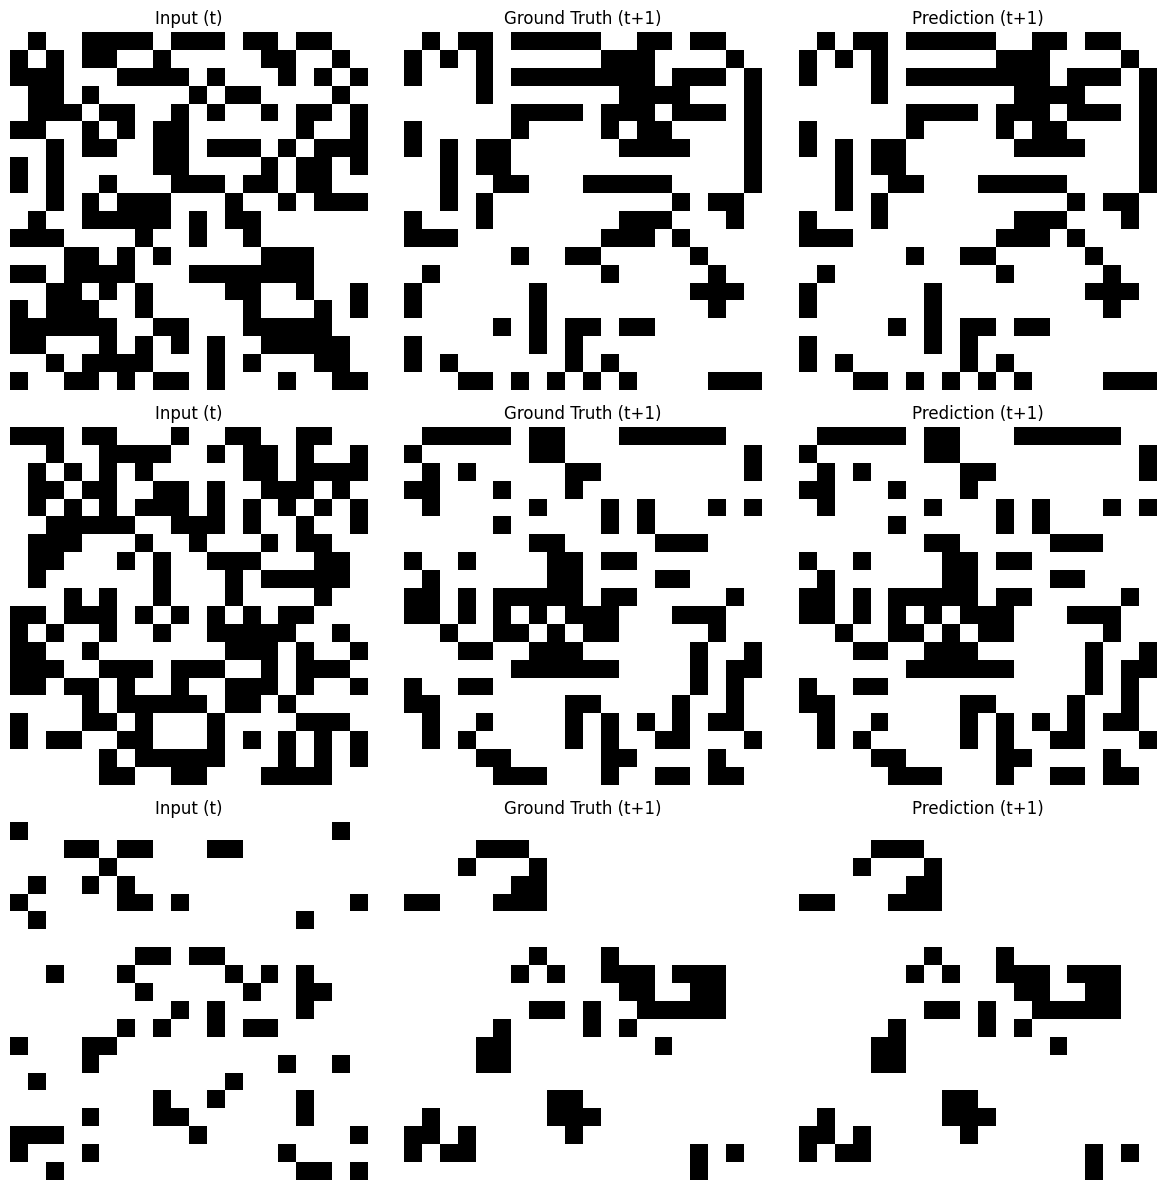

In [12]:
def visualize_predictions(model, X, y, num_samples=3):
    preds = model.predict(X[:num_samples])
    preds_binary = (preds > 0.5).astype(np.float32)
    
    plt.figure(figsize=(12, 4 * num_samples))
    for i in range(num_samples):
        # Input
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(X[i, :, :, 0], cmap='binary')
        plt.title("Input (t)")
        plt.axis('off')
        
        # Ground Truth
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(y[i, :, :, 0], cmap='binary')
        plt.title("Ground Truth (t+1)")
        plt.axis('off')
        
        # Prediction
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(preds_binary[i, :, :, 0], cmap='binary')
        plt.title("Prediction (t+1)")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_predictions(model, X_val, y_val)

## 6. Minimal Model Experiment (Rebutting "Hardness")

The original paper claims that "minimal" architectures rarely converge. We used 64 filters above, which is robust. Let's try a much smaller model (e.g., 10 filters) to see if our diverse data generation allows even constrained models to learn easily.

In [13]:
def build_minimal_model(grid_size):
    model = models.Sequential([
        layers.Input(shape=(grid_size, grid_size, 1)),
        # Minimal filters (e.g., 10)
        layers.Conv2D(10, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(10, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(1, (1, 1), padding='same', activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

print("Training Minimal Model (10 filters)...")
minimal_model = build_minimal_model(GRID_SIZE)
minimal_model.summary()

history_min = minimal_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=0 # Silent training
)

pixel_acc_min, exact_match_acc_min = evaluate_exact_match(minimal_model, X_val, y_val)
print(f"Minimal Model - Pixel-wise Accuracy: {pixel_acc_min * 100:.4f}%")
print(f"Minimal Model - Exact Match Accuracy: {exact_match_acc_min * 100:.4f}%")

Training Minimal Model (10 filters)...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 20, 20, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 20, 20, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 20, 20, 1)      │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,021 (3.99 KB)

 Trainable params: 1,021 (3.99 KB)

 Non-trainable params: 0 (0.00 B)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Minimal Model - Pixel-wise Accuracy: 100.0000%
Minimal Model - Exact Match Accuracy: 100.0000%
